In [1]:
import os
import torch
from torch import nn
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision import transforms
import numpy as np
import scipy as sp


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 10971017.02it/s]


Extracting /content/MNIST/raw/train-images-idx3-ubyte.gz to /content/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 350951.12it/s]


Extracting /content/MNIST/raw/train-labels-idx1-ubyte.gz to /content/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 3211877.35it/s]


Extracting /content/MNIST/raw/t10k-images-idx3-ubyte.gz to /content/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 3738329.82it/s]


Extracting /content/MNIST/raw/t10k-labels-idx1-ubyte.gz to /content/MNIST/raw

Starting epoch 1
Loss after mini-batch     1: 2.28182 
Loss after mini-batch   101: 2.26661 
Loss after mini-batch   201: 2.22356 
Loss after mini-batch   301: 2.17173 
Epoch train accuracy: 0.21458333333333332
Test accuracy: 0.5191666666666667
Starting epoch 2
Loss after mini-batch     1: 2.12077 
Loss after mini-batch   101: 2.01124 
Loss after mini-batch   201: 1.86540 
Loss after mini-batch   301: 1.54689 
Epoch train accuracy: 0.5992222222222222
Test accuracy: 0.7082916666666667
Starting epoch 3
Loss after mini-batch     1: 1.43066 
Loss after mini-batch   101: 1.15872 
Loss after mini-batch   201: 0.92464 
Loss after mini-batch   301: 0.86334 
Epoch train accuracy: 0.7717777777777778
Test accuracy: 0.814625
Starting epoch 4
Loss after mini-batch     1: 0.68687 
Loss after mini-batch   101: 0.84903 
Loss after mini-batch   201: 0.78765 
Loss after mini-batch   301: 0.54929 
Epoch train accuracy: 0.83441

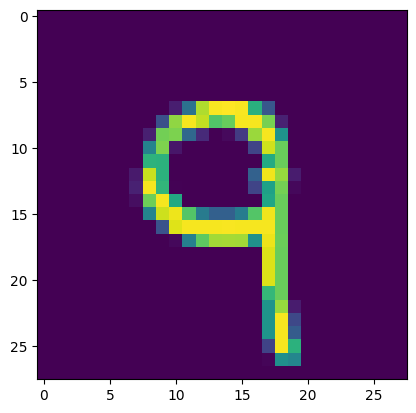

In [2]:


class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      nn.Flatten(),
      nn.Linear(28 * 28, 30),
      # nn.Dropout(0.1),
      nn.ReLU(),
      nn.Linear(30,20),
      nn.ReLU(),
      nn.Linear(20,10),
      #nn.Softmax()
    )

  def forward(self, x):
    '''Forward pass'''
    return self.layers(x)
  def compute_l1_loss(self, w):
      return torch.abs(w).sum()
  def compute_l2_loss(self, w):
      return (torch.abs(w)**2).sum()

if __name__ == '__main__':
  # Set fixed random number seed
  torch.manual_seed(42)
  # Prepare CIFAR-10 dataset
  dataset = MNIST(os.getcwd(), download=True, transform=transforms.ToTensor())
  train_size = int(0.6 * len(dataset))
  test_size = len(dataset) - train_size
  train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])
  trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=100, shuffle=True, num_workers=1)
  testLoader = torch.utils.data.DataLoader(test_dataset, batch_size = test_size, shuffle=True, num_workers = 1)
  # Initialize the MLP
  mlp = MLP()
  # Define the loss function and optimizer
  loss_function = nn.CrossEntropyLoss()
  # optimizer = torch.optim.SGD(mlp.parameters(),lr=1e-5,momentum=0.8)
  optimizer = torch.optim.SGD(mlp.parameters(), lr=0.01)

  # Run the training loop
  for epoch in range(0, 10): # 5 epochs at maximum
    # Print epoch
    print(f'Starting epoch {epoch+1}')
    # Iterate over the DataLoader for training data
    totalDataNum = 0
    accurateCount = 0;
    for i, data in enumerate(trainloader, 0):
      # Get inputs
      inputs, targets = data
      totalDataNum += targets.shape[0];
      # Zero the gradients
      optimizer.zero_grad()
      # Perform forward pass
      outputs = mlp(inputs)
      # Compute loss
      loss = loss_function(outputs, targets)
      # # Compute regularization loss component
      Regul_weight = 0
      RegulParameters = []
      for parameter in mlp.parameters():
          RegulParameters.append(parameter.view(-1))
      # RegulLoss = Regul_weight * mlp.compute_l1_loss(torch.cat(RegulParameters))
      RegulLoss = Regul_weight * mlp.compute_l2_loss(torch.cat(RegulParameters))
      # Add Regularization loss component
      loss += RegulLoss
      # Perform backward pass
      loss.backward()
      # Perform optimization
      optimizer.step()
      # Print statistics
      minibatch_loss = loss.item()
      if i % 100 == 0:
          # print('Loss after mini-batch %5d: %.5f (of which %.5f L1 loss)' %
          #       (i + 1, minibatch_loss, l1))
        print('Loss after mini-batch %5d: %.5f ' %
              (i + 1, minibatch_loss))

      current_loss = 0.0
      maxPos = np.argmax( outputs.detach().numpy(),1)
      labels = targets.detach().numpy()
      accurateCount += (maxPos == labels).sum()
    if (accurateCount/totalDataNum) >= 0.9:
      print('Pre-defined training accuracy reached at: '+str(accurateCount/totalDataNum))
      break

    print('Epoch train accuracy: '+str(accurateCount/totalDataNum))
    with torch.no_grad():
      test_accurateCount = 0
      for i, data in enumerate(testLoader, 0):
        test_inputs, test_targets = data
        test_output = mlp(test_inputs)
        maxPos = np.argmax( test_output.detach().numpy(),1)
        test_labels = test_targets.detach().numpy()
        test_accuracy = (maxPos == test_labels).mean()
        print('Test accuracy: '+str(test_accuracy))
  # Process is complete.
  print('Training has finished.')

  from matplotlib import pyplot as plt


  sample_x = inputs[0,:,:,:].reshape([28,28])
  plt.figure(0)
  plt.imshow(sample_x.reshape([28,28]))#, extent=[-1, 1, -1, 1])
  plt.show()

Pass patterns in Layer 1


<ipython-input-3-4b80072c1a9d>:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(fc)


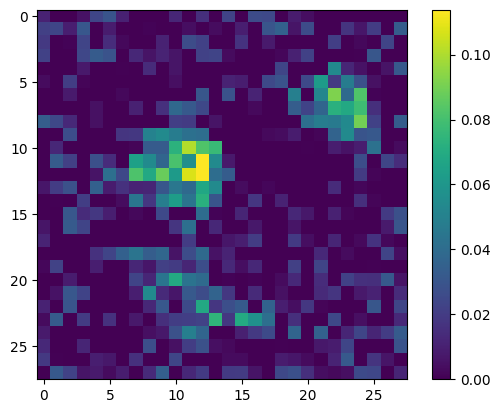

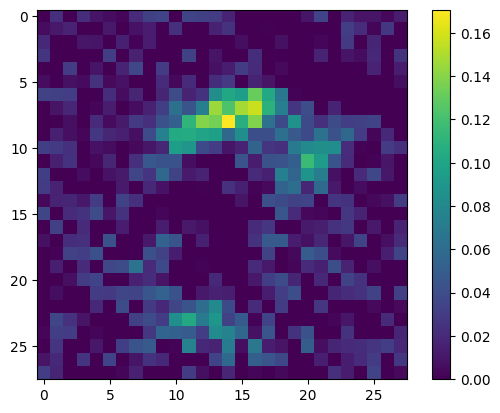

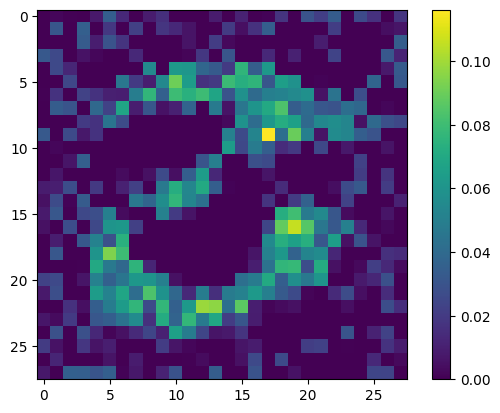

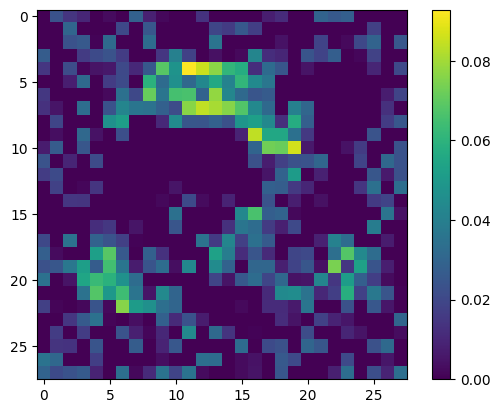

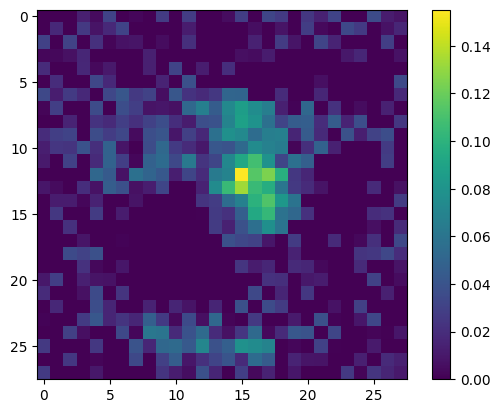

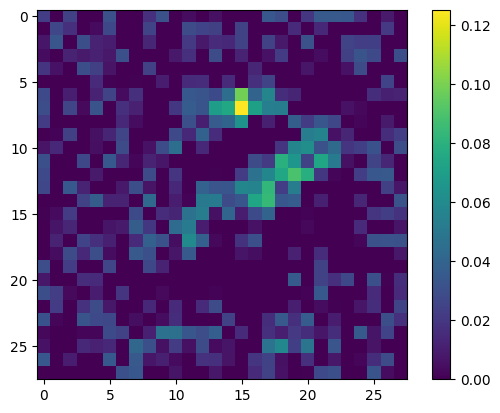

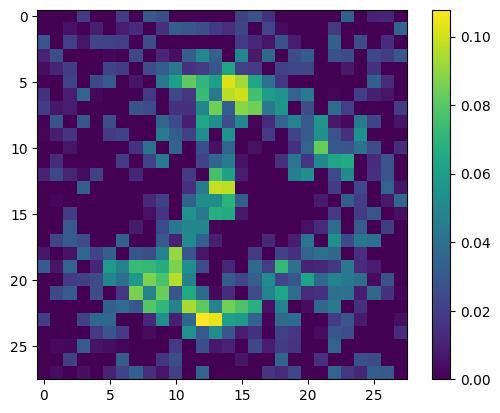

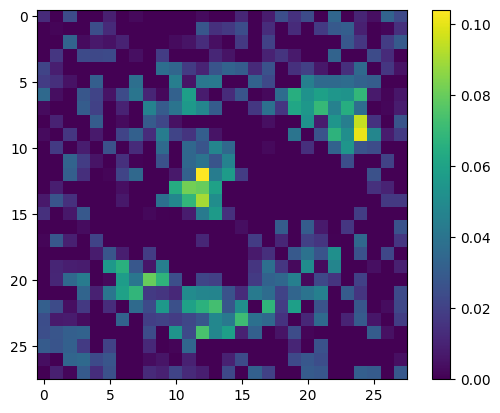

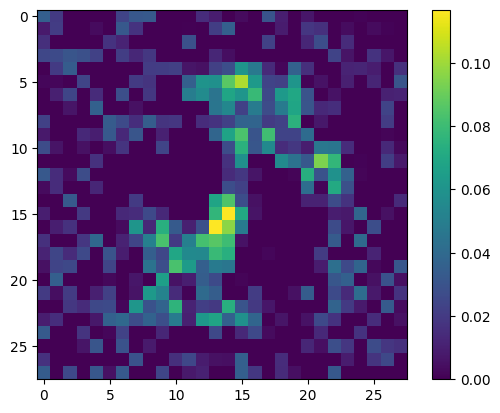

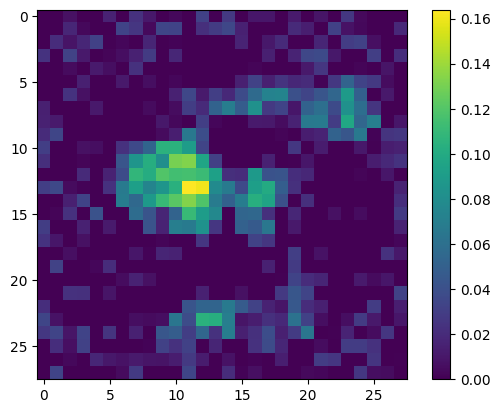

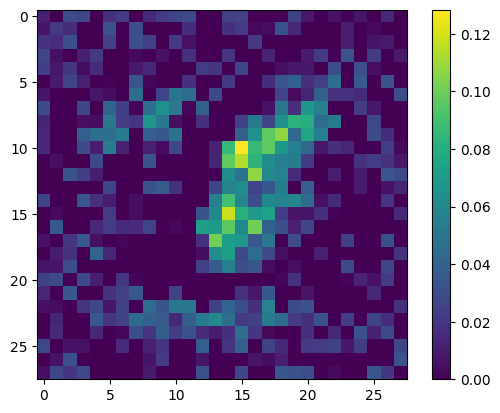

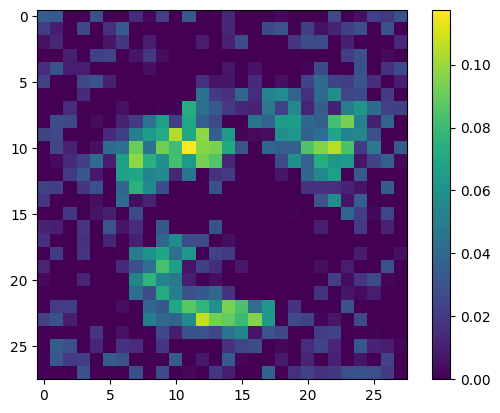

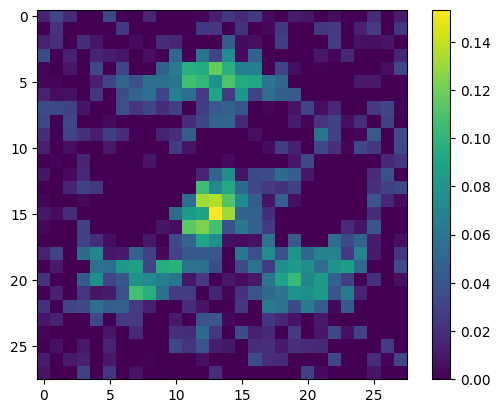

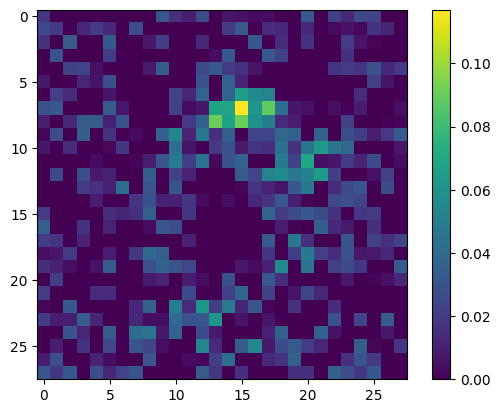

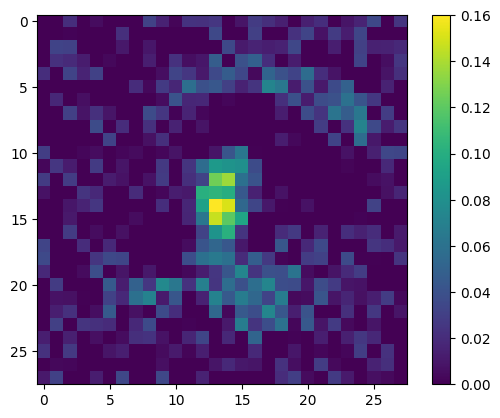

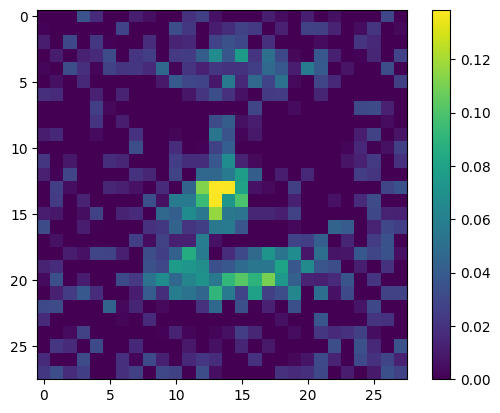

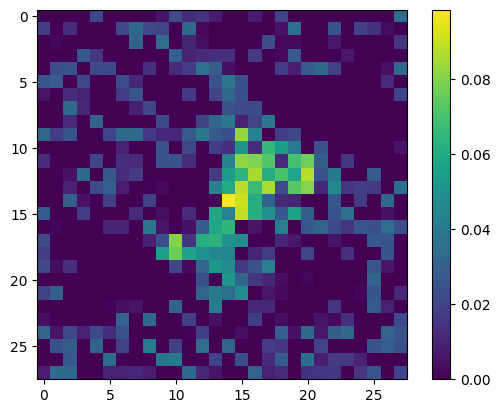

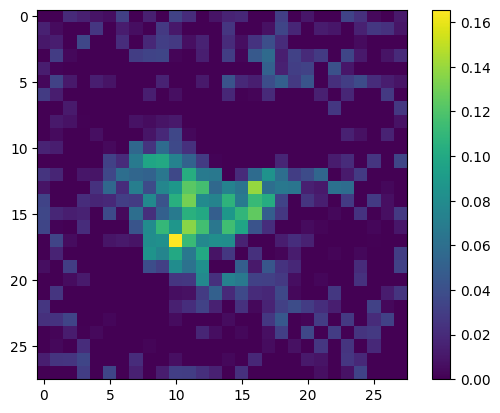

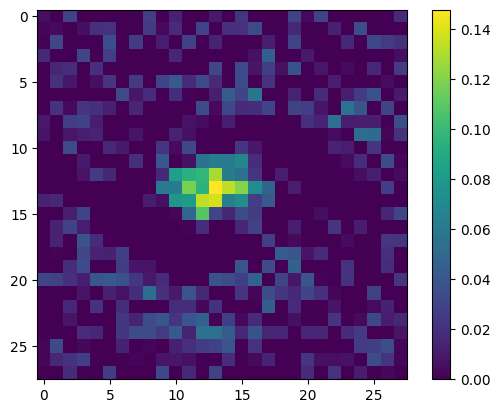

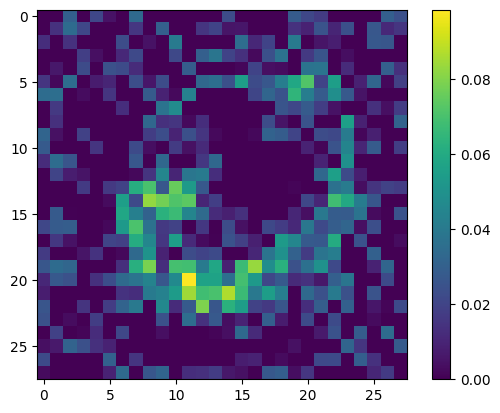

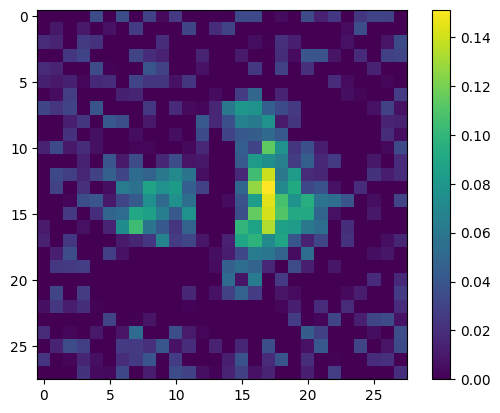

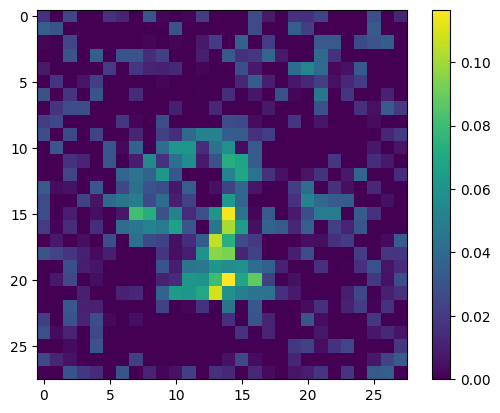

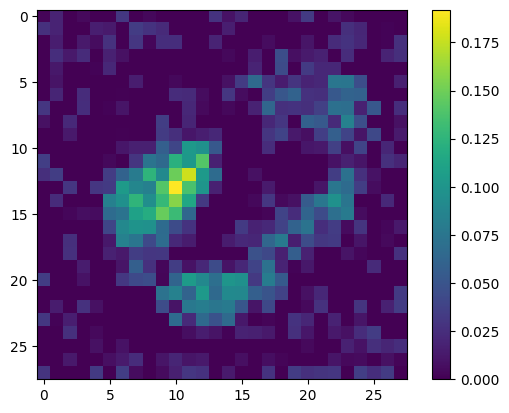

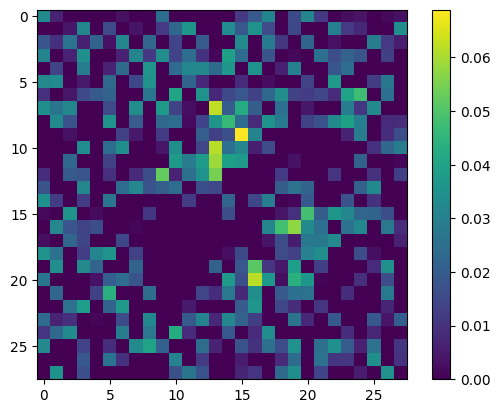

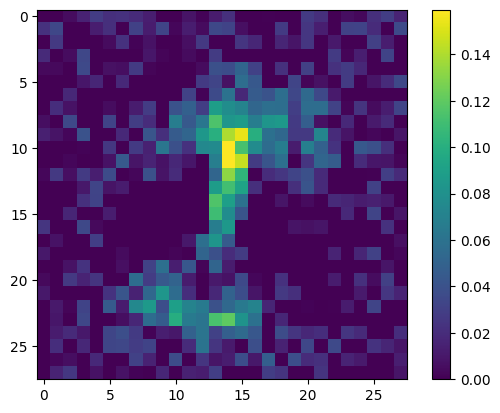

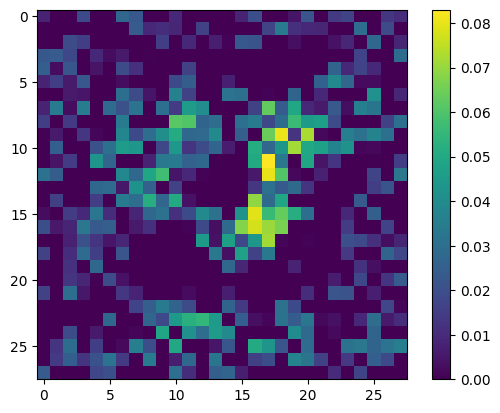

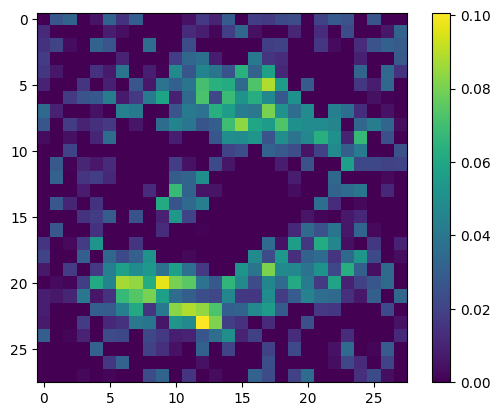

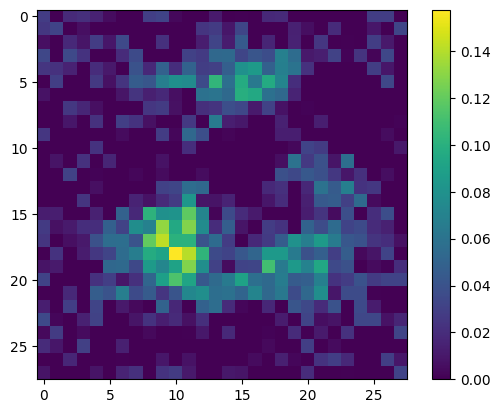

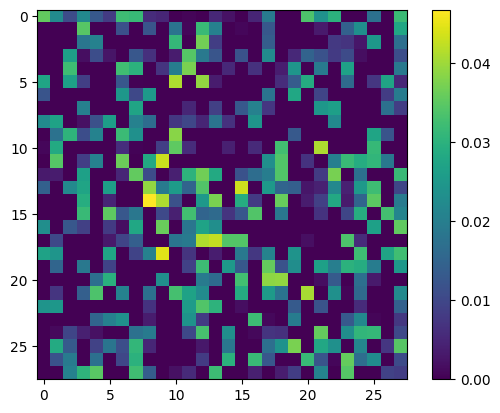

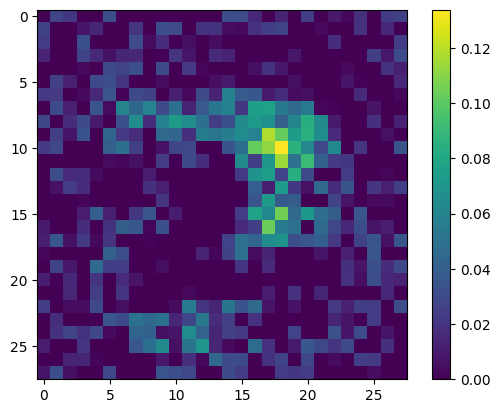

In [3]:
  l1 = (mlp.layers[1].weight).detach().numpy()
  l1_p = torch.relu(torch.tensor(l1))
  fc = 0
  print('Pass patterns in Layer 1')
  for i in range(l1.shape[0]):
    plt.figure(fc)
    fc = fc+1
    mask_i = l1_p[i,:];
    mask_i = mask_i.reshape([28,28])
    # plt.imshow(mask_i, vmin=-0.25, vmax=0.25)
    plt.imshow(mask_i)
    plt.colorbar()


Blended pass patterns in Layer 


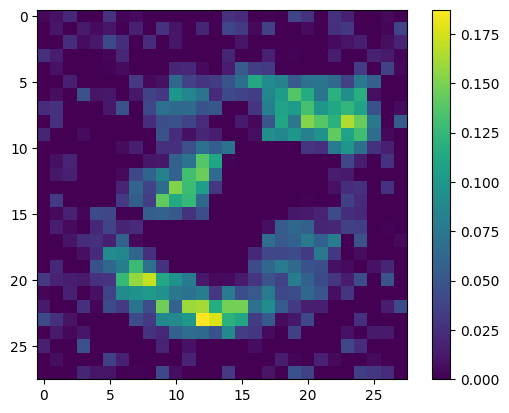

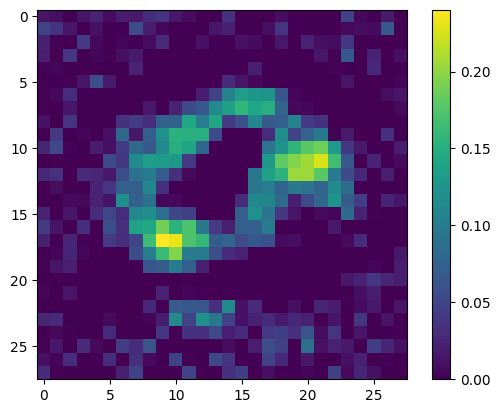

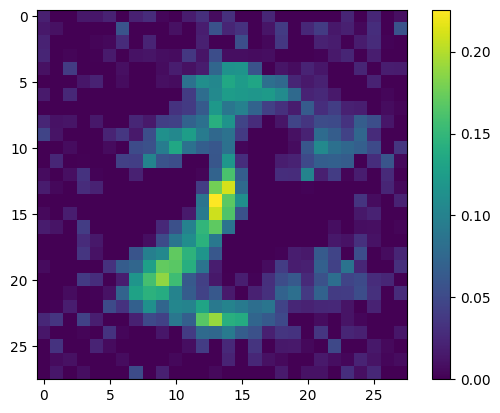

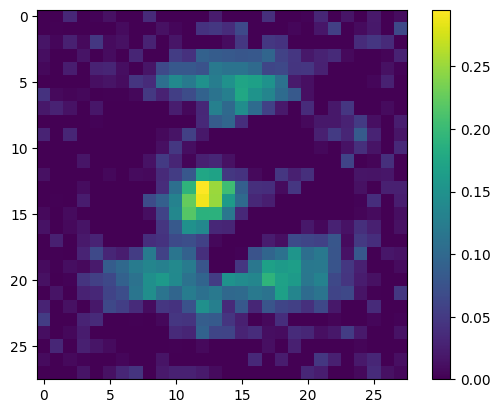

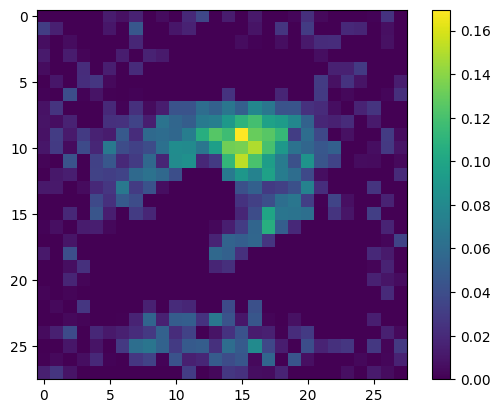

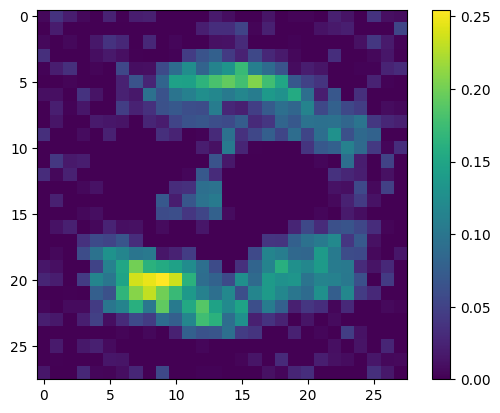

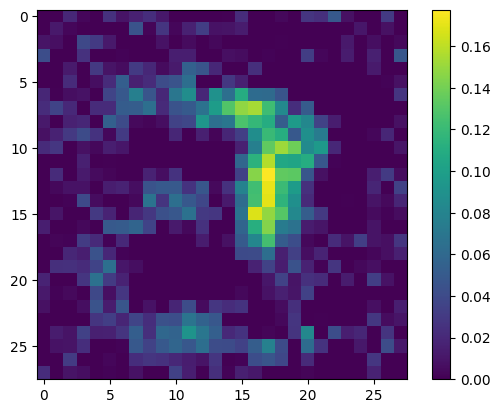

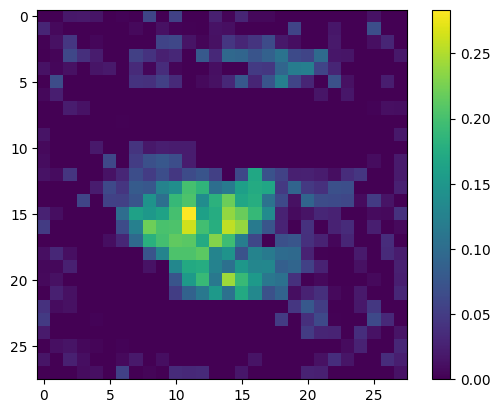

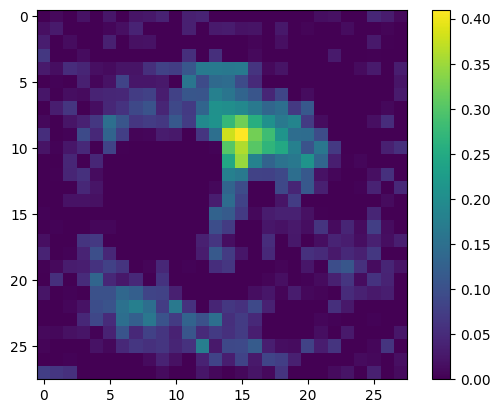

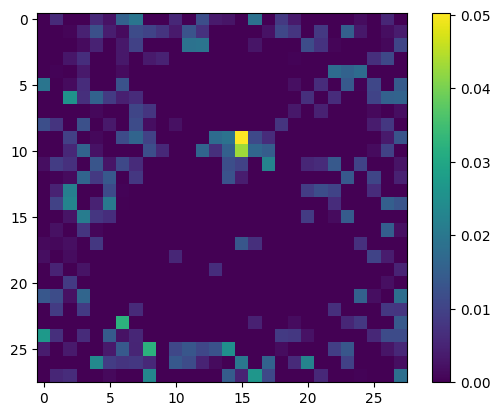

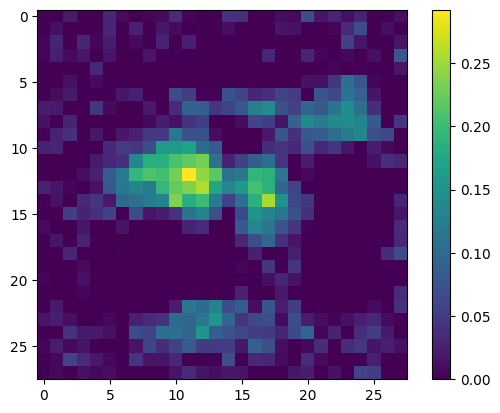

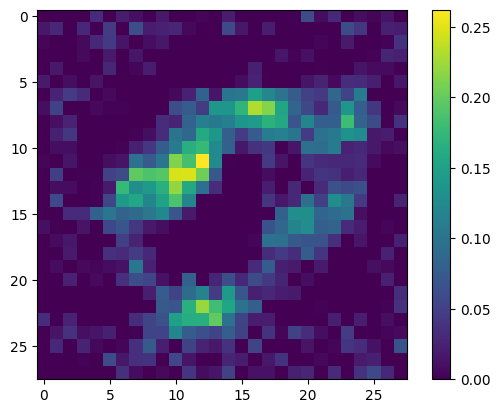

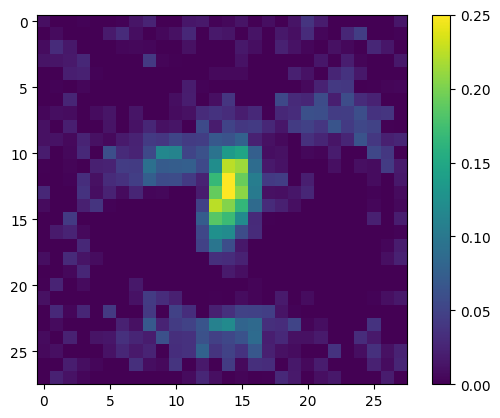

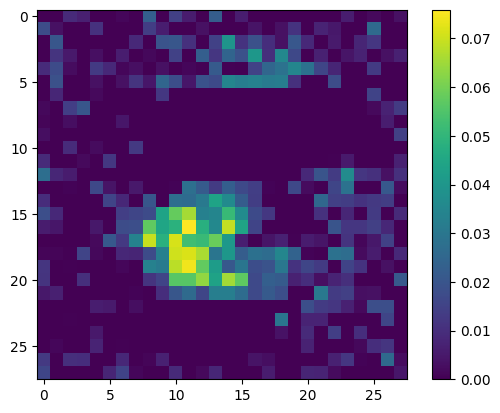

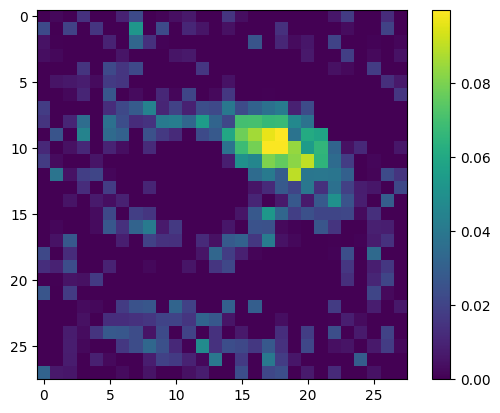

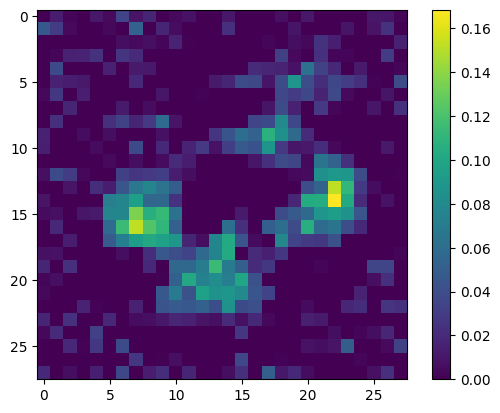

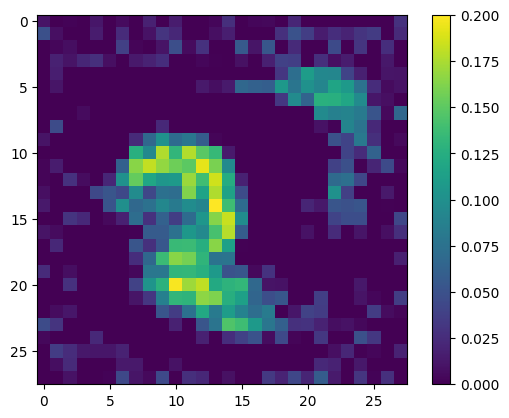

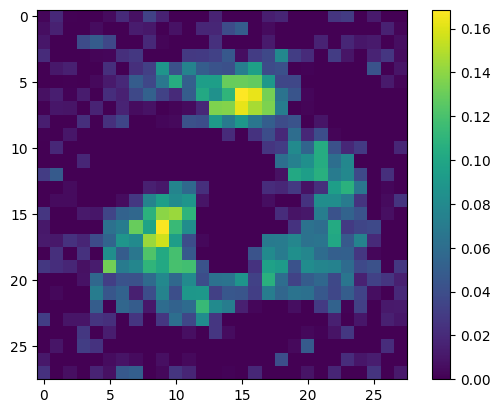

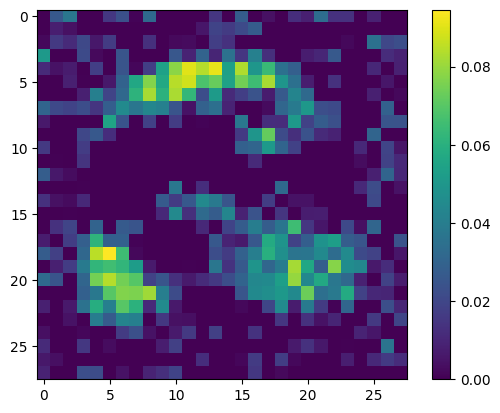

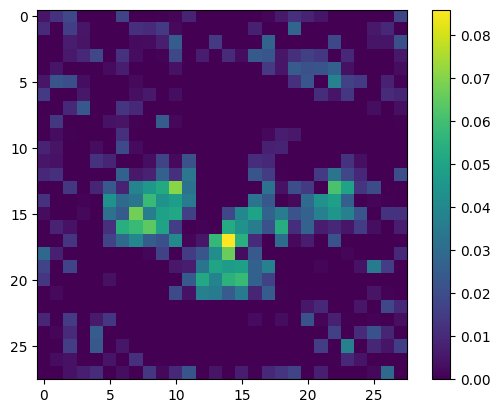

In [7]:

  l3 = (mlp.layers[3].weight).detach().numpy()
  fused = torch.relu(torch.tensor(np.matmul(l3,l1)))
  # fused = torch.tensor(np.matmul(l3,l1))


  print('Blended pass patterns in Layer ')
  for i in range(fused.shape[0]):
    plt.figure(fc)
    fc = fc+1
    mask_i = fused[i,:]
    mask_i = mask_i.reshape([28,28])
    plt.imshow(mask_i, vmin=-0.25, vmax=0.25)
    plt.imshow(mask_i)
    plt.colorbar()

array([[0.01099812, 0.        , 0.        , ..., 0.02440692, 0.        ,
        0.01176529],
       [0.        , 0.02332306, 0.        , ..., 0.03476297, 0.        ,
        0.00438   ],
       [0.        , 0.00187601, 0.00071772, ..., 0.02417215, 0.02389623,
        0.        ],
       ...,
       [0.0281681 , 0.        , 0.01863593, ..., 0.        , 0.        ,
        0.03195052],
       [0.03546749, 0.02255815, 0.01085084, ..., 0.        , 0.00919604,
        0.00851679],
       [0.        , 0.02807855, 0.02146038, ..., 0.0046105 , 0.        ,
        0.        ]], dtype=float32)

<ipython-input-19-35497f0a0041>:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fused = torch.tensor(


torch.Size([10, 784])
Blended pass patterns in Layer 3:


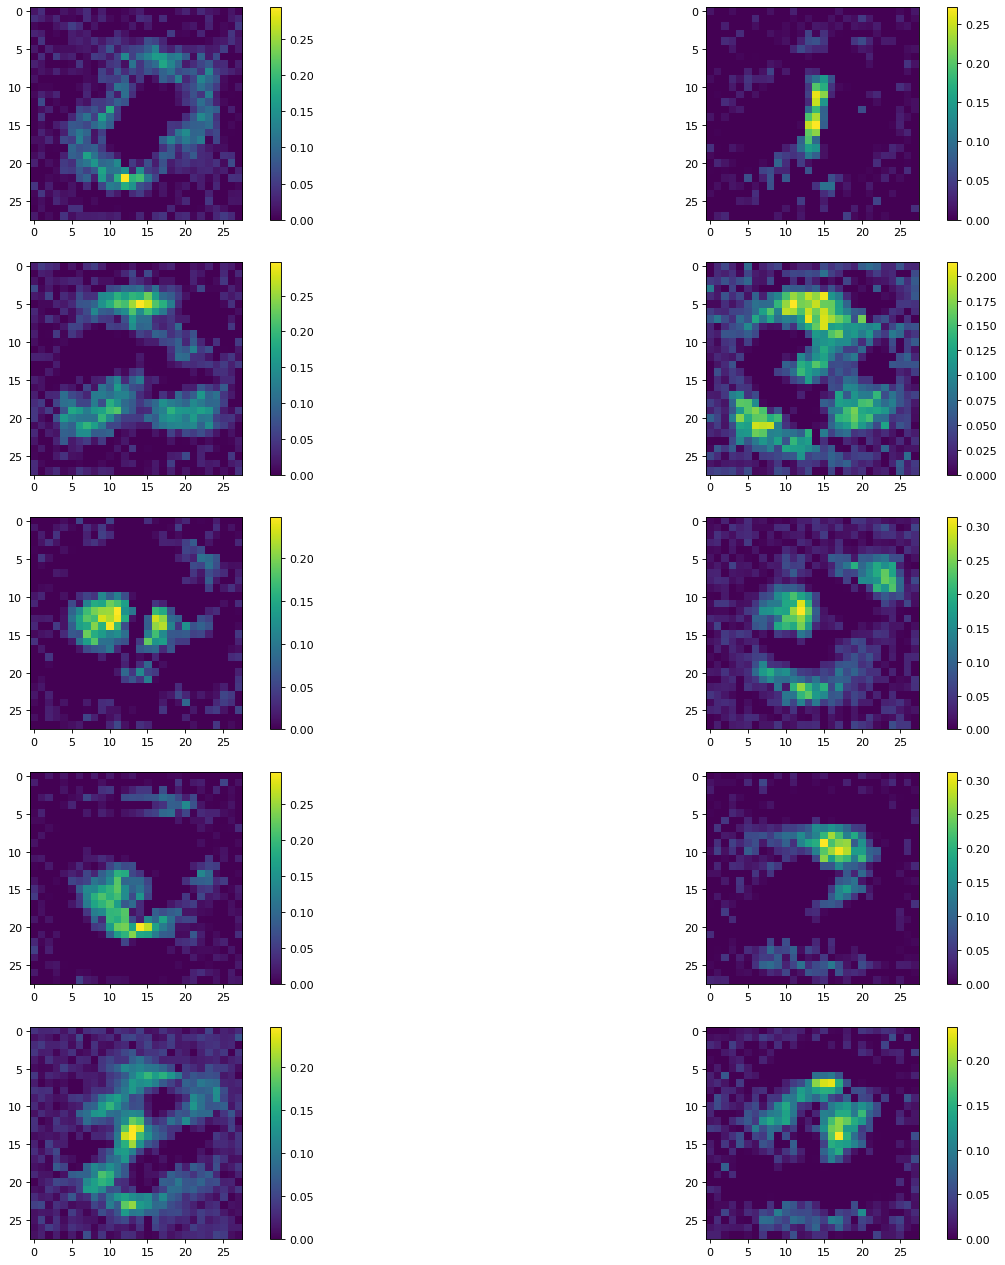

In [19]:
  l5 = (mlp.layers[5].weight).detach().numpy()

  # fused = torch.tensor(
  #                     np.matmul(l5,torch.relu(torch.tensor(np.matmul(l3,l1)) )))
  fused = torch.tensor(
                      np.matmul(l5,torch.relu(torch.matmul(torch.tensor(l3),torch.relu(torch.tensor(l1)) )) ))

  fused = torch.relu(fused)
  print(fused.size())
  print('Blended pass patterns in Layer 3:')
  plt.figure(figsize=(20, 20), dpi=80)
  plt.tight_layout()
  for i in range(fused.shape[0]):
    # plt.figure(fc)
    # fc = fc+1
    plt.subplot(5,2,i+1)
    mask_i = fused[i,:]
    mask_i = mask_i.reshape([28,28])
    # plt.imshow(mask_i, vmin=-0.25, vmax=0.25)
    plt.imshow(mask_i)
    plt.colorbar()